In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# display settings
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

In [15]:
# ===== PATHS =====
SMALL_PATH = "../results/captum_attributions/captum_small_run/captum_results_2.csv"
FULL_PATH = "../results/captum_attributions/complete_run/captum_results_1.csv"
SUMMARY_PATH = "../results/language_analysis/captum_tokens_summary.csv"
TOP_FEATURES_PATH = "../results/language_analysis/top_language_features.csv"

# ===== LOAD =====
df_small = pd.read_csv(SMALL_PATH)
df_full = pd.read_csv(FULL_PATH)
df_summary = pd.read_csv(SUMMARY_PATH)
df_features = pd.read_csv(TOP_FEATURES_PATH)

print("Small:", df_small.shape)
print("Full:", df_full.shape)
print("Summary:", df_summary.shape)
print("Top features:", df_features.shape)

Small: (28878, 8)
Full: (151374, 8)
Summary: (544, 6)
Top features: (115, 6)


In [16]:
df_small_clean = df_small[df_small["delta_flagged"] == False]
df_full_clean = df_full[df_full["delta_flagged"] == False]

print("Small clean:", df_small_clean.shape)
print("Full clean:", df_full_clean.shape)

Small clean: (21707, 8)
Full clean: (69167, 8)


In [17]:
def get_top_tokens(df, top_n=20):
    return (
        df.groupby(["label", "token"])["abs_attribution"]
        .mean()
        .reset_index()
        .sort_values(["label", "abs_attribution"], ascending=[True, False])
        .groupby("label")
        .head(top_n)
    )

top_small = get_top_tokens(df_small_clean)
top_full = get_top_tokens(df_full_clean)

# merge to compare overlap
comparison = pd.merge(
    top_small,
    top_full,
    on=["label", "token"],
    suffixes=("_small", "_full")
)

comparison.head(20)

,label,token,abs_attribution_small,abs_attribution_full
0,authority_appeal,presidential,0.247324,0.247104
1,authority_appeal,foothold,0.213800,0.212399
2,authority_appeal,preconditions,0.212058,0.211570
3,authority_appeal,disarmament,0.204333,0.204347
4,emotion_appeal,antisemitism,0.315616,0.311709
5,emotion_appeal,delighted,0.207978,0.271632
6,exaggeration,refugee,0.277638,0.279686
7,exaggeration,disadvantage,0.261606,0.259240
8,exaggeration,bombings,0.257132,0.259970
9,polarization,bombings,0.297679,0.299182


In [18]:
for label in df_summary["label"].unique():
    print(f"\n=== {label} ===")
    display(
        df_summary[df_summary["label"] == label]
        .sort_values("weighted_importance", ascending=False)
        .head(10)
    )


=== authority_appeal ===


,label,token,mean_importance,frequency,frequency_pct,weighted_importance
0,authority_appeal,year,0.100022,6.0,0.037037,0.194634
1,authority_appeal,jobs,0.140165,3.0,0.018519,0.194309
2,authority_appeal,work,0.073871,12.0,0.074074,0.189476
3,authority_appeal,economy,0.088992,6.0,0.037037,0.173170
4,authority_appeal,tonight,0.119504,3.0,0.018519,0.165667
5,authority_appeal,century,0.099743,4.0,0.024691,0.160531
6,authority_appeal,workers,0.096010,4.0,0.024691,0.154523
7,authority_appeal,country,0.062341,10.0,0.061728,0.149487
8,authority_appeal,effort,0.107176,3.0,0.018519,0.148577
9,authority_appeal,questions,0.089520,4.0,0.024691,0.144077



=== exaggeration ===


,label,token,mean_importance,frequency,frequency_pct,weighted_importance
108,exaggeration,work,0.085614,12.0,0.093750,0.219596
109,exaggeration,nation,0.128159,4.0,0.031250,0.206264
110,exaggeration,tough,0.141206,3.0,0.023438,0.195753
111,exaggeration,america,0.098332,6.0,0.046875,0.191344
112,exaggeration,world,0.097838,6.0,0.046875,0.190385
113,exaggeration,faith,0.116569,3.0,0.023438,0.161599
114,exaggeration,challenge,0.088699,4.0,0.031250,0.142755
115,exaggeration,support,0.077969,5.0,0.039062,0.139701
116,exaggeration,let,0.069084,6.0,0.046875,0.134432
117,exaggeration,working,0.072976,5.0,0.039062,0.130755



=== rhetorical_framing ===


...

,label,token,mean_importance,frequency,frequency_pct,weighted_importance
276,emotion_appeal,tough,0.159438,3.0,0.021277,0.221028
277,emotion_appeal,people,0.100296,7.0,0.049645,0.208561
278,emotion_appeal,love,0.135272,3.0,0.021277,0.187526
279,emotion_appeal,hope,0.134827,3.0,0.021277,0.186909
280,emotion_appeal,country,0.075554,9.0,0.063830,0.173968
281,emotion_appeal,future,0.107264,4.0,0.028369,0.172634
282,emotion_appeal,faith,0.119946,3.0,0.021277,0.166280
283,emotion_appeal,peace,0.085950,5.0,0.035461,0.154002
284,emotion_appeal,world,0.077318,5.0,0.035461,0.138536
285,emotion_appeal,america,0.071927,5.0,0.035461,0.128877



=== polarization ===


,label,token,mean_importance,frequency,frequency_pct,weighted_importance
358,polarization,work,0.096314,8.0,0.059259,0.211623
359,polarization,year,0.092988,6.0,0.044444,0.180946
360,polarization,office,0.100252,4.0,0.029630,0.161349
361,polarization,jobs,0.111626,3.0,0.022222,0.154746
362,polarization,effort,0.095416,4.0,0.029630,0.153567
363,polarization,support,0.072061,6.0,0.044444,0.140224
364,polarization,working,0.076343,5.0,0.037037,0.136788
365,polarization,military,0.094697,3.0,0.022222,0.131278
366,polarization,believe,0.093036,3.0,0.022222,0.128975
367,polarization,faith,0.087824,3.0,0.022222,0.121750



=== presumption ===


,label,token,mean_importance,frequency,frequency_pct,weighted_importance
440,presumption,tough,0.168319,3.0,0.018293,0.233339
441,presumption,rights,0.136670,4.0,0.024390,0.219962
442,presumption,freedom,0.153337,3.0,0.018293,0.212570
443,presumption,america,0.073000,10.0,0.060976,0.175046
444,presumption,president,0.096922,4.0,0.024390,0.155990
445,presumption,challenge,0.086800,5.0,0.030488,0.155525
446,presumption,support,0.075600,6.0,0.036585,0.147112
447,presumption,tonight,0.088631,4.0,0.024390,0.142646
448,presumption,working,0.076829,5.0,0.030488,0.137659
449,presumption,year,0.062124,7.0,0.042683,0.129183


In [19]:
GENERIC = {
    "people", "country", "work", "world", "government",
    "time", "year", "today", "things", "way"
}

df_summary_filtered = df_summary[~df_summary["token"].isin(GENERIC)]

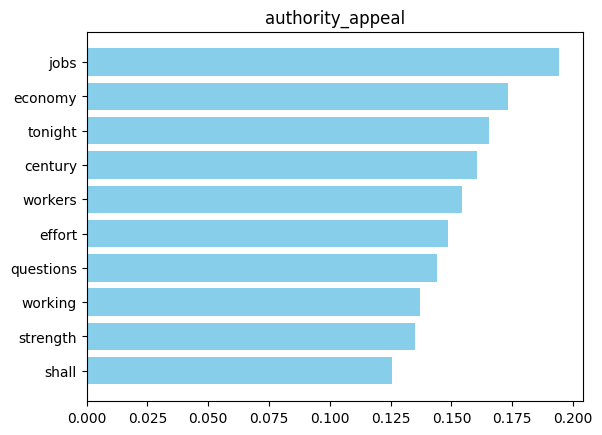

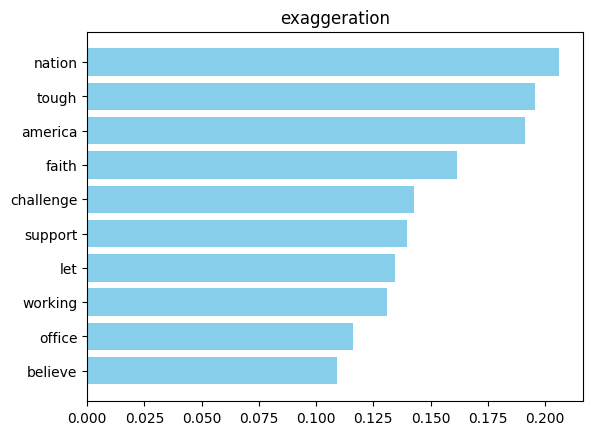

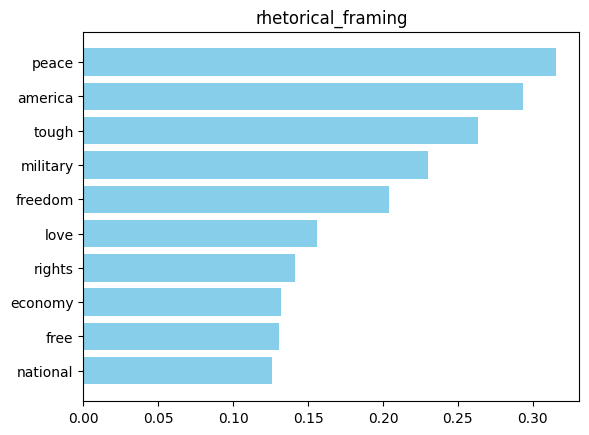

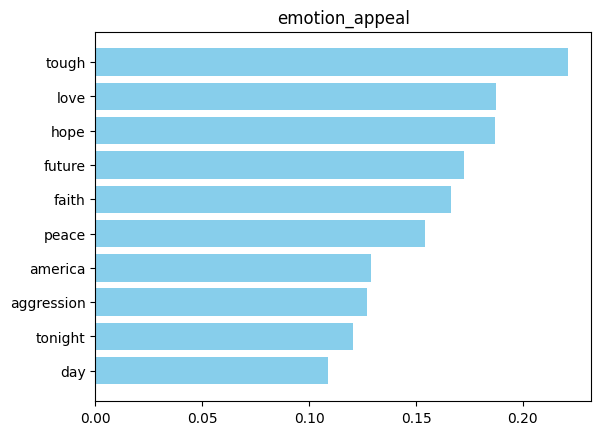

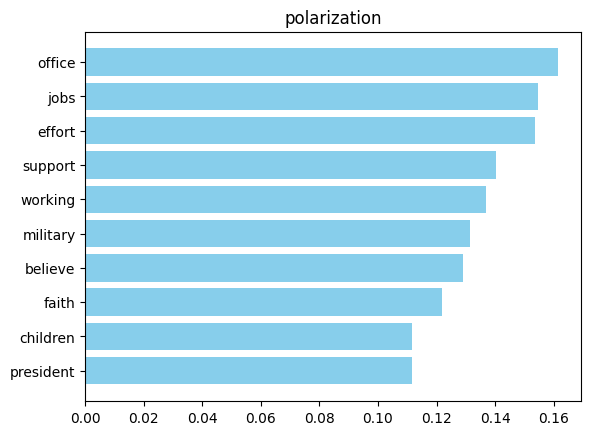

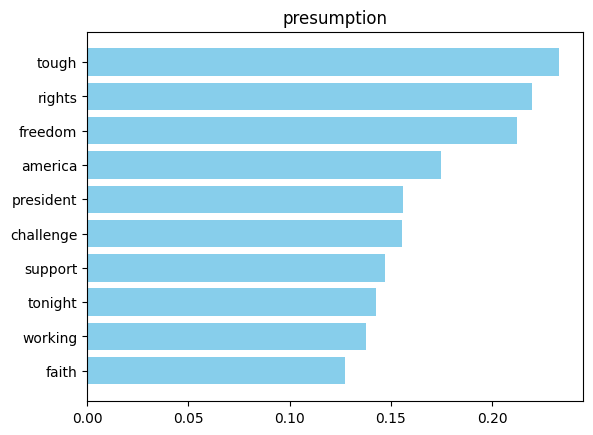

In [37]:
def plot_top_tokens(df, label, top_n=10):
    subset = (
        df[df["label"] == label]
        .sort_values("weighted_importance", ascending=False)
        .head(top_n)
    )
    
    plt.figure()
    plt.barh(subset["token"], subset["weighted_importance"], color="skyblue")
    plt.title(label)
    plt.gca().invert_yaxis()
    plt.show()

for label in df_summary_filtered["label"].unique():
    plot_top_tokens(df_summary_filtered, label)

In [23]:
df_features = df_features.rename(columns={"feature": "token"})

In [24]:
# normalize column names if needed
df_features.columns = [c.lower() for c in df_features.columns]

# assume df_features has: label, feature/token
merged = pd.merge(
    df_summary_filtered,
    df_features,
    left_on=["label", "token"],
    right_on=["label", "token"],
    how="inner"
)

merged.sort_values("weighted_importance", ascending=False).head(20)

,label,token,mean_importance,frequency_x,frequency_pct,weighted_importance,type,score,frequency_y,rank
3,rhetorical_framing,peace,0.151634,7.0,0.045161,0.315314,word,0.018277,28,4
4,rhetorical_framing,america,0.127317,9.0,0.058065,0.293158,word,0.018615,39,3
5,rhetorical_framing,freedom,0.147198,3.0,0.019355,0.204060,word,0.016111,20,5
2,exaggeration,america,0.098332,6.0,0.046875,0.191344,word,0.076794,7,1
11,emotion_appeal,hope,0.134827,3.0,0.021277,0.186909,word,0.025635,16,2
6,rhetorical_framing,economy,0.067822,6.0,0.038710,0.131976,word,0.010388,17,15
19,presumption,free,0.050818,8.0,0.048780,0.111658,word,0.017444,10,8
12,emotion_appeal,families,0.056324,5.0,0.035461,0.100919,word,0.012923,11,15
20,presumption,know,0.060514,4.0,0.024390,0.097393,word,0.022311,9,2
0,authority_appeal,states,0.045673,6.0,0.037037,0.088876,word,0.090823,8,5


In [25]:
coverage = []

for label in df_summary_filtered["label"].unique():
    captum_tokens = set(df_summary_filtered[df_summary_filtered["label"] == label]["token"])
    feature_tokens = set(df_features[df_features["label"] == label]["token"])
    
    overlap = captum_tokens & feature_tokens
    
    coverage.append({
        "label": label,
        "captum_tokens": len(captum_tokens),
        "feature_tokens": len(feature_tokens),
        "overlap": len(overlap),
        "overlap_ratio": len(overlap) / max(len(captum_tokens), 1)
    })

coverage_df = pd.DataFrame(coverage)
coverage_df

,label,captum_tokens,feature_tokens,overlap,overlap_ratio
0,authority_appeal,99,12,2,0.020202
1,exaggeration,72,6,1,0.013889
2,rhetorical_framing,78,30,8,0.102564
3,emotion_appeal,73,30,6,0.082192
4,polarization,73,10,2,0.027397
5,presumption,95,27,6,0.063158


In [39]:
overlap_analysis = []

for label in df_summary_filtered["label"].unique():
    captum_tokens = set(df_summary_filtered[df_summary_filtered["label"] == label]["token"])
    feature_tokens = set(df_features[df_features["label"] == label]["token"])
    
    overlap = captum_tokens & feature_tokens
    
    overlap_analysis.append({
        "label": label,
        "overlap_count": len(overlap),
        "captum_only": len(captum_tokens - overlap),
        "features_only": len(feature_tokens - overlap),
        "overlap_ratio": len(overlap) / max(len(feature_tokens), 1)
    })

pd.DataFrame(overlap_analysis)

,label,overlap_count,captum_only,features_only,overlap_ratio
0,authority_appeal,2,97,10,0.166667
1,exaggeration,1,71,5,0.166667
2,rhetorical_framing,8,70,22,0.266667
3,emotion_appeal,6,67,24,0.200000
4,polarization,2,71,8,0.200000
5,presumption,6,89,21,0.222222


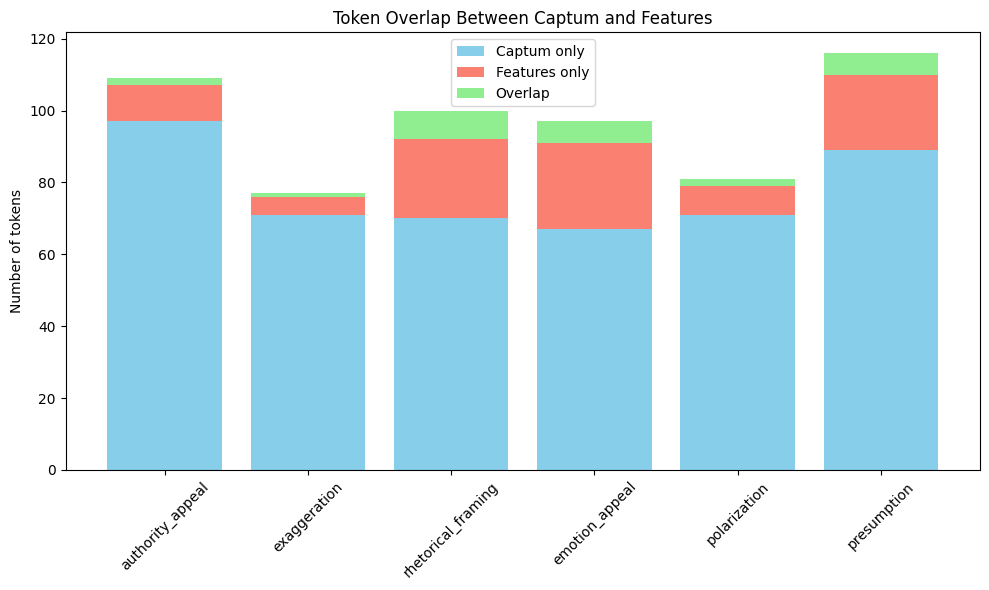

/var/folders/qs/b6gl60rs5p720hcg1ll48zqh0000gn/T/ipykernel_7035/4197945309.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


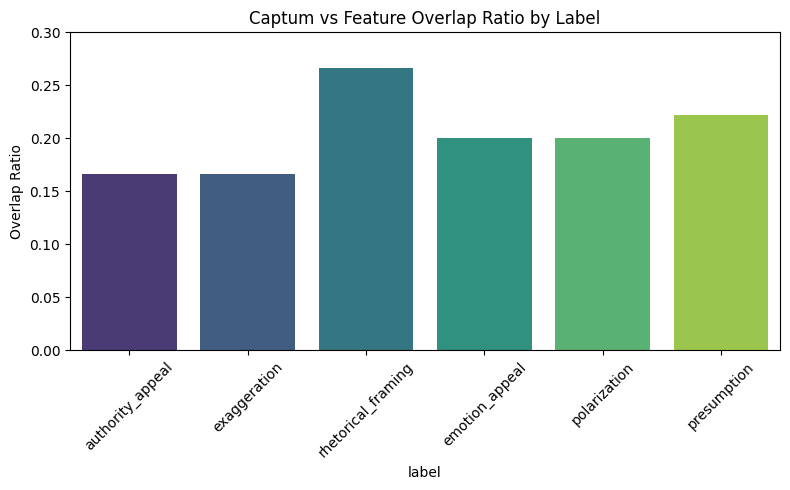

In [45]:
# Create DataFrame from overlap analysis
overlap_df = pd.DataFrame(overlap_analysis)

# Stacked bar chart
labels = overlap_df['label']
captum_only = overlap_df['captum_only']
features_only = overlap_df['features_only']
overlap_count = overlap_df['overlap_count']

plt.figure(figsize=(10,6))
plt.bar(labels, captum_only, label='Captum only', color='skyblue')
plt.bar(labels, features_only, bottom=captum_only, label='Features only', color='salmon')
plt.bar(labels, overlap_count, bottom=captum_only+features_only, label='Overlap', color='lightgreen')

plt.ylabel("Number of tokens")
plt.title("Token Overlap Between Captum and Features")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Overlap ratio bar chart
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(
    x="label",
    y="overlap_ratio",
    data=overlap_df,
    palette="viridis"
)
plt.ylabel("Overlap Ratio")
plt.title("Captum vs Feature Overlap Ratio by Label")
plt.ylim(0, 0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

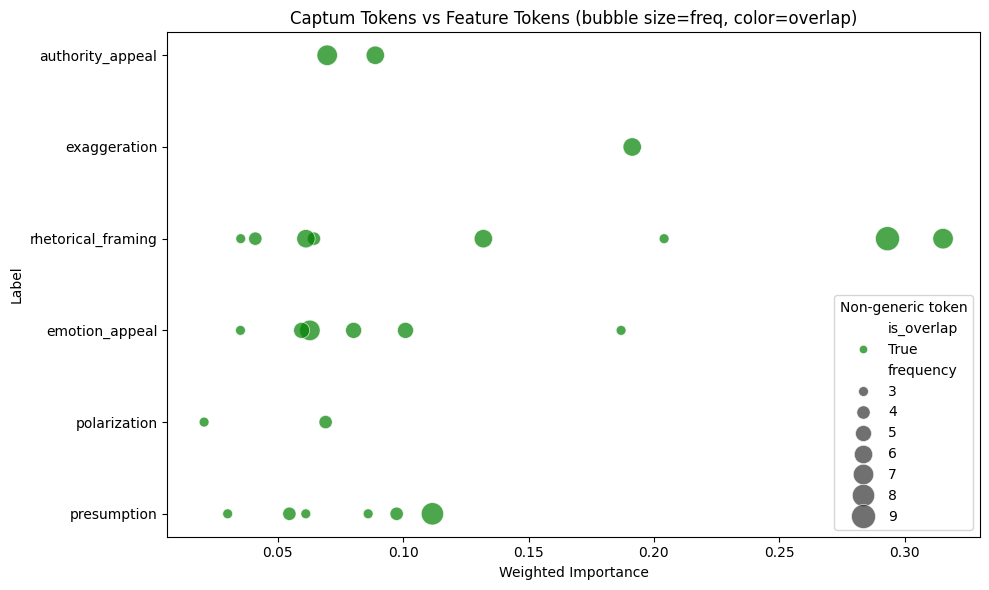

In [47]:
freq_map = df_summary_filtered.set_index(["label","token"])["frequency"].to_dict()
merged["frequency"] = merged.apply(lambda row: freq_map.get((row.label, row.token), 1), axis=1)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x="weighted_importance",
    y="label",
    size="frequency",
    hue="is_overlap",
    palette={True: 'green', False: 'grey'},
    alpha=0.7,
    sizes=(50, 300)
)
plt.xlabel("Weighted Importance")
plt.ylabel("Label")
plt.title("Captum Tokens vs Feature Tokens (bubble size=freq, color=overlap)")
plt.legend(title="Non-generic token")
plt.tight_layout()
plt.show()

In [6]:
import json
from pathlib import Path
import pandas as pd

BASE_PATH = Path("../results")

rows = []

for metrics_file in BASE_PATH.rglob("test_metrics.json"):
    model_name = metrics_file.parent.name

    with open(metrics_file) as f:
        metrics = json.load(f)

    # 🔥 Normalize different formats
    if "macro_f1" in metrics:  # baseline models
        f1_macro = metrics["macro_f1"]
        precision_macro = metrics.get("micro_precision", None)
        recall_macro = metrics.get("micro_recall", None)

    elif "eval_f1_macro" in metrics:  # distilbert
        f1_macro = metrics["eval_f1_macro"]
        precision_macro = metrics.get("eval_precision", None)
        recall_macro = metrics.get("eval_recall", None)

    else:
        print(f"Unknown format: {model_name}")
        continue

    rows.append({
        "model": model_name,
        "f1_macro": f1_macro,
        "precision": precision_macro,
        "recall": recall_macro,
    })

df_models = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)

df_models 

,model,f1_macro,precision,recall
1,distilbert_20260323_181219,0.403852,0.302326,0.989848
0,baseline_20260324_092448,0.402400,0.535600,0.725900
2,baseline_20260324_092215,0.402400,0.535600,0.725900
6,lr,0.402400,0.535600,0.725900
5,svm,0.378800,0.554200,0.700500
3,distilbert_20260407_094939,0.321803,0.218889,1.000000
4,dummy,0.123200,0.586700,0.446700


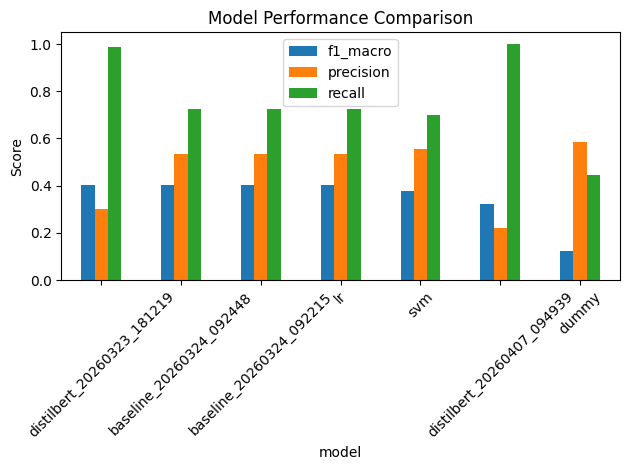

In [7]:
import matplotlib.pyplot as plt

df_models.set_index("model")[["f1_macro", "precision", "recall"]].plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

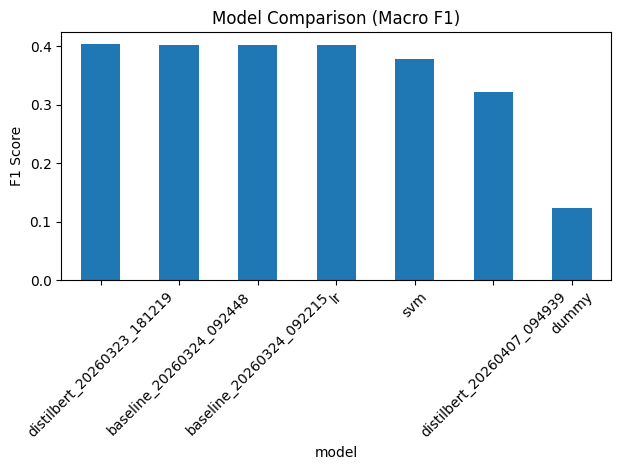

In [8]:
df_models.set_index("model")["f1_macro"].plot(kind="bar")

plt.title("Model Comparison (Macro F1)")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

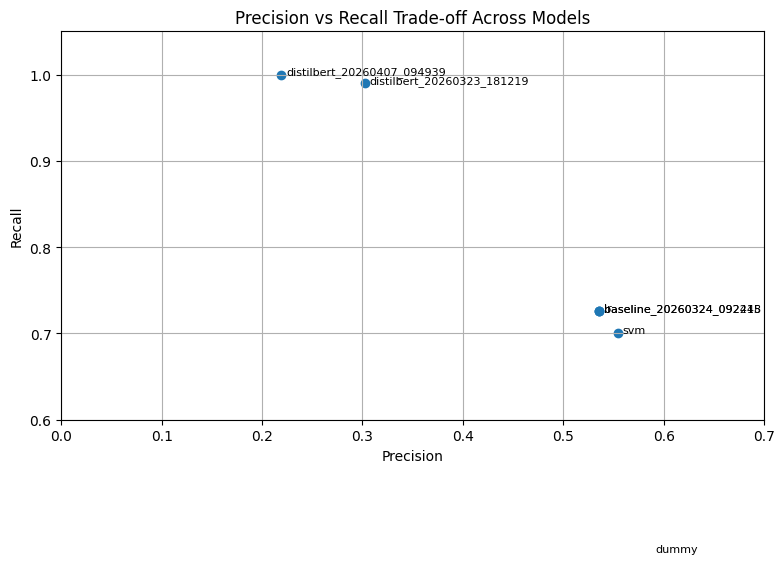

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(df_models["precision"], df_models["recall"])

for i, row in df_models.iterrows():
    plt.text(row["precision"] + 0.005, row["recall"], row["model"], fontsize=8)

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision vs Recall Trade-off Across Models")

plt.xlim(0, 0.7)
plt.ylim(0.6, 1.05)

plt.grid(True)
plt.tight_layout()
plt.show()

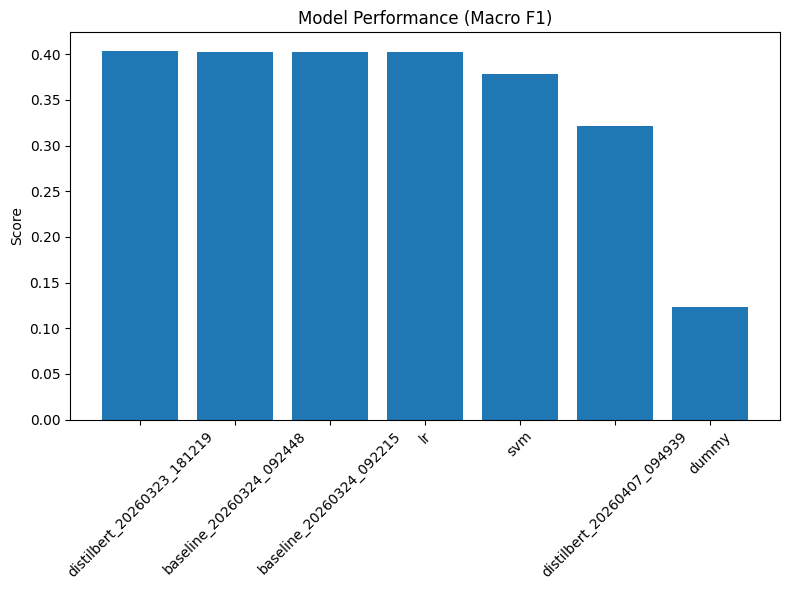

In [10]:
plt.figure(figsize=(8,6))

plt.bar(df_models["model"], df_models["f1_macro"], label="F1")
plt.xticks(rotation=45)

plt.ylabel("Score")
plt.title("Model Performance (Macro F1)")
plt.tight_layout()
plt.show()